In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [2]:
!find /kaggle/input -type f

/kaggle/input/datasets/jigishadas/dataset/ast_features_final (1).csv


In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/jigishadas/dataset/ast_features_final (1).csv"
)

df.head()

,function_count,parameter_count,variable_count,declaration_count,if_count,for_count,while_count,switch_count,return_count,call_count,...,identifier_density,expression_density,variable_density,statement_density,nesting_factor,cyclomatic_estimate,avg_parameters,language,repository,function
0,1,2,2,1,1,0,0,0,0,4,...,0.194805,0.025974,0.025974,0.025974,0.129870,2,2.0,java,molgenis/molgenis,L1Cache.put
1,1,0,7,4,1,1,0,0,1,1,...,0.195876,0.010309,0.072165,0.010309,0.092784,3,0.0,java,belaban/JGroups,RequestTable.size
2,1,3,8,4,0,0,0,0,0,17,...,0.148410,0.010601,0.028269,0.010601,0.045936,1,3.0,java,googleads/googleads-java-lib,DownloadCriteriaReportWithAwql.runExample
3,1,4,0,0,0,0,0,0,1,2,...,0.176471,0.000000,0.000000,0.000000,0.117647,1,4.0,java,Azure/azure-sdk-for-java,NetworkInterfacesInner.updateTagsAsync
4,2,6,4,2,6,0,0,0,3,12,...,0.110070,0.002342,0.009368,0.002342,0.037471,7,3.0,java,Azure/azure-sdk-for-java,BlobContainersInner.extendImmutabilityPolicyWi...


In [4]:
print(df.shape)

df.info()

(2000, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   function_count           2000 non-null   int64  
 1   parameter_count          2000 non-null   int64  
 2   variable_count           2000 non-null   int64  
 3   declaration_count        2000 non-null   int64  
 4   if_count                 2000 non-null   int64  
 5   for_count                2000 non-null   int64  
 6   while_count              2000 non-null   int64  
 7   switch_count             2000 non-null   int64  
 8   return_count             2000 non-null   int64  
 9   call_count               2000 non-null   int64  
 10  argument_count           2000 non-null   int64  
 11  assignment_count         2000 non-null   int64  
 12  binary_expression_count  2000 non-null   int64  
 13  identifier_count         2000 non-null   int64  
 14  block_count  

In [5]:
metadata = df[["language", "repository", "function"]]

X = df.drop(
    columns=[
        "language",
        "repository",
        "function"
    ]
)

print(X.shape)

(2000, 32)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(2000, 32)


In [7]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

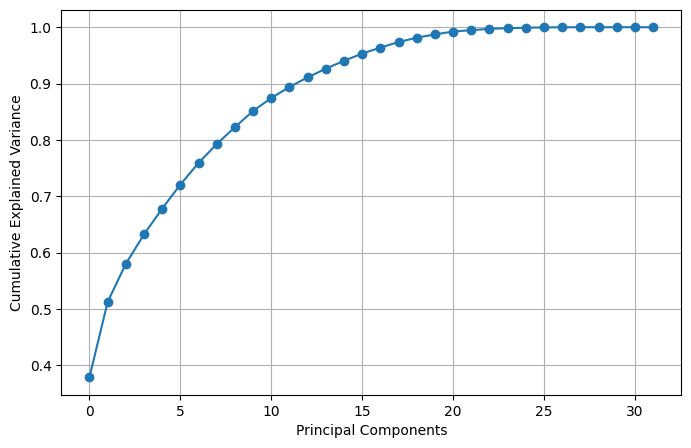

In [8]:
import numpy as np
import matplotlib.pyplot as plt

explained = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(explained),
    marker="o"
)

plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.grid(True)

plt.show()

In [9]:
cumulative = np.cumsum(explained)

for i, value in enumerate(cumulative, start=1):
    print(f"PC{i}: {value:.4f}")

PC1: 0.3789
PC2: 0.5125
PC3: 0.5801
PC4: 0.6324
PC5: 0.6782
PC6: 0.7208
PC7: 0.7592
PC8: 0.7926
PC9: 0.8227
PC10: 0.8514
PC11: 0.8744
PC12: 0.8940
PC13: 0.9110
PC14: 0.9265
PC15: 0.9404
PC16: 0.9533
PC17: 0.9638
PC18: 0.9737
PC19: 0.9814
PC20: 0.9873
PC21: 0.9923
PC22: 0.9948
PC23: 0.9971
PC24: 0.9982
PC25: 0.9991
PC26: 0.9997
PC27: 0.9999
PC28: 1.0000
PC29: 1.0000
PC30: 1.0000
PC31: 1.0000
PC32: 1.0000


In [10]:
df["SSI"] = X_pca[:, 0]

df[["SSI"]].head()

,SSI
0,-1.407771
1,-0.685910
2,0.810129
3,-2.041741
4,2.781887


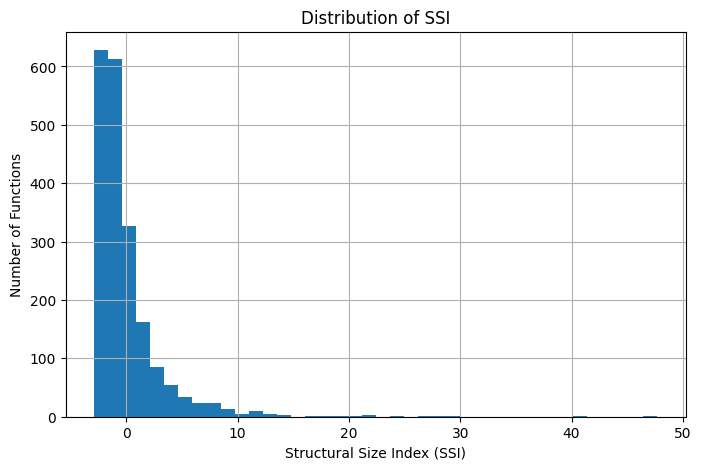

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["SSI"], bins=40)

plt.xlabel("Structural Size Index (SSI)")
plt.ylabel("Number of Functions")
plt.title("Distribution of SSI")

plt.grid(True)

plt.show()

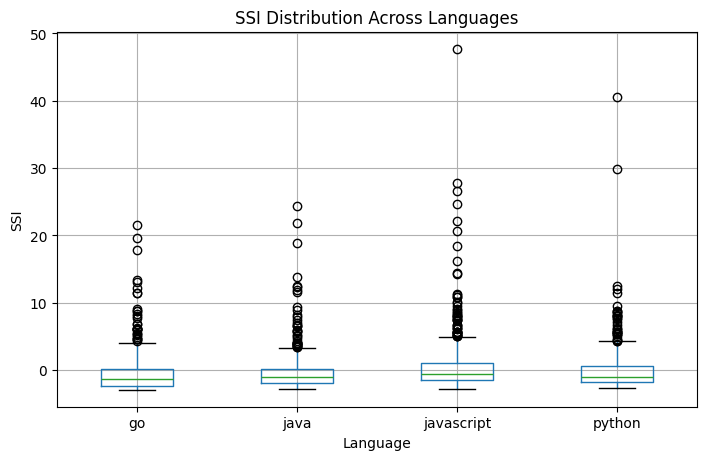

In [12]:
import matplotlib.pyplot as plt

df.boxplot(column="SSI", by="language", figsize=(8,5))

plt.title("SSI Distribution Across Languages")
plt.suptitle("")
plt.xlabel("Language")
plt.ylabel("SSI")

plt.show()

In [13]:
df.to_csv(
    "/kaggle/working/dataset_with_ssi.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!
